In [12]:
from dotenv import load_dotenv
load_dotenv(".env", override=True)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Deepagent for Research

`deepagents` 패키지를 사용할 때에는 중요한 것들이 있다.
1. 내장 도구들의 이해가 가능해야 한다.
2. 업무에 특화된 도구를 주입한다.
3. 업무에 특화된 지시를 내린다.
4. 업무에 특화된 서브 에이전트를 준다.

## Task-Specific Tools

### Search Tool
다양한 검색 도구들 중, 여기서는 **Tavily**를 사용해 유사한 URL들을 찾아낸 다음 웹 페이지의 전체 내용을 가져올 것이다.

### Think Tool
이 도구는 에이전트의 의사결정을 감독하기에 유용하다.

In [13]:
from research_agent.tools import tavily_search, think_tool
tools = [tavily_search, think_tool]

## Task-Specific Instructions
https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA

### 1. Think Like The Agent
너의 새로운 동료에게 어떤 지시를 내릴거야?

- Read the question carefully - 사용자가 어떤 특정 정보를 원하는가?
- Start wuth broader search - 처음에는 넓고 포괄적인 쿼리를 사용해
- After each search, pause and assess - 나의 대답이 충분했나? 무언가를 놓치고 있나?
- Execute narrower searches as you gather information - 빈 간격을 채워라

### 2. Concrete Heuristics (Prevent "Spin-Out" on excessive tool calls)
**Hard Limits**를 사용해서 검색 에이전트의 과도한 도구 사용을 예방한다.
- Stop when you can answer confidently - 완벽을 위해 계속 검색하지 마라
- Give it budgets - 간단한 쿼리에는 2-3개의 도구를, 복잡한 쿼리에는 5개까지의 도구를 사용해라.
- Limit - 만약 답을 찾지 못하더라도 5개의 도구를 호출한 뒤에는 반드시 멈춰라.

### 3. Show your thinking
매 검색 도구 호출 후에는 `think_tool`를 사용해 결과를 분석해라.
- 어떤 중요한 정보를 찾았는가?
- 무엇을 놓쳤나?
- 질문을 포괄적으로 하기 위한 충분한 답이 되는가?
- 추가 검색 혹은 나의 견해를 추가해야 하는가?

In [14]:
from datetime import datetime
from utils import show_prompt, format_messages
from research_agent.prompts import (
    RESEARCHER_INSTRUCTIONS,
    RESEARCH_WORKFLOW_INSTRUCTIONS,
    SUBAGENT_DELEGATION_INSTRUCTIONS,   
)

In [15]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the research tools provided to you to find resources that can help answer the research      │
│  question.                                                                                                      │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Research Tools>                                                                                     │
│  You have access to two specific research tools:                                                                │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Research Tools>                                                                                    │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

### Task-Specific Sub-Agents
컨텍스트 독림을 위해 서브에이전트를 커스텀할 수 있다.
아래는 웹에서 정보를 검색하는 서브 에이전트가 정의돼있다.

In [16]:
# Get current date
current_date = datetime.now().strftime("%Y-%m-%d")

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search, think_tool],
}

### Putting it all together
#### Instructions
모든 지시를 동시에 볼 수 있다.

In [17]:
# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Combine orchestrator instructions (RESEARCHERINSTRUCTIONS only for sub-agents)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 88
    + "\n\n"
    + SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Research Workflow                                                                                            │
│                                                                                                                 │
│  Follow this workflow for all research requests:                                                                │
│                                                                                                                 │
│  1. **Plan**: Create a todo list with write_todos to break down the research into focused tasks                 │
│  2. **Save the request**: Use write_file() to save the user's research question to `/research_request.md`       │
│  3. **Research**: Delegate research tasks to sub-agents using the task() tool - ALWAYS use sub-agents for       │
│  research, never conduct research yourself                                                                      │
│  4. **Synthesize**: Review all sub-agent findings and consolidate citations (each unique URL gets one number    │
│  across all findings)                                                                                           │
│  5. **Write Report**: Write a comprehensive final report to `/final_report.md` (see Report Writing Guidelines   │
│  below)                                                                                                         │
│  6. **Verify**: Read `/research_request.md` and confirm you've addressed all aspects with proper citations and  │
│  structure                                                                                                      │
│                                                                                                                 │
│  ## Research Planning Guidelines                                                                                │
│  - Batch similar research tasks into a single TODO to minimize overhead                                         │
│  - For simple fact-finding questions, use 1 sub-agent                                                           │
│  - For comparisons or multi-faceted topics, delegate to multiple parallel sub-agents                            │
│  - Each sub-agent should research one specific aspect and return findings                                       │
│                                                                                                                 │
│  ## Report Writing Guidelines                                                                                   │
│                                                                                                                 │
│  When writing the final report to `/final_report.md`, follow these structure patterns:                          │
│                                                                                                                 │
│  **For comparisons:**                                                                                           │
│  1. Introduction                                                                                                │
│  2. Overview of topic A                                                                                         │
│  3. Overview of topic B                                                                                         │
│  4. Detailed comparison                                                                                         │
│  5. Conclusion                                                                                                  │
│                                                                                                                 │
│  **For lists/rankings:**                              

### Create the agent
이제 이 요소들을 사용해 딥에이전트를 만든다.

In [18]:
from IPython.display import Image, display
from deepagents import create_deep_agent
from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI

# model gpt-5
model = ChatOpenAI(model="gpt-5", temperature=1)

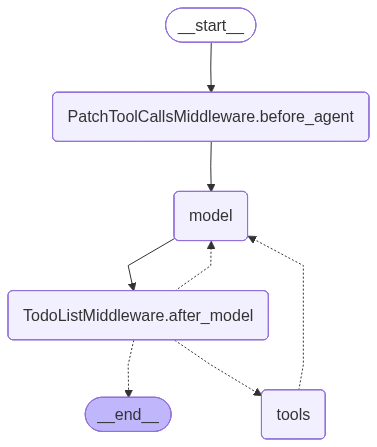

In [19]:
# Create the agent
agent = create_deep_agent(
    model=model,
    tools=tools,
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent],
)

# show the agent
display(Image(agent.get_graph().draw_mermaid_png()))

In [ ]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "research context engineering approaches used to build AI agents",
            }
        ]
    }
)
format_messages(result['messages'])